### Exploratory Data Analysis (EDA)
The goal of this notebook is to 

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import chi2_contingency
import sys
import os
import numpy as np

project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

df_cleaned=preprocess_data(file_path)
df_cleaned.to_csv(output_path, index=False)

%matplotlib inline
sns.set_style("whitegrid")

Dropping columns with > 50% missing values: smoking, tjc_28, sjc_28, vas


In [87]:
patient_complete = df_cleaned.groupby("patient_id").apply(lambda x: x.notna().all().all())

# patients with complete data
complete_patients = patient_complete[patient_complete].index.tolist()

print("Number of patients with complete data:", len(complete_patients))


Number of patients with complete data: 22


In [88]:
#Missinness if I exclude patients without DAS28 scores

patients_no_das28 = df_cleaned.groupby('patient_id')['das28_score'].apply(lambda x: x.isna().all())
patients_no_das28 = patients_no_das28.index[patients_no_das28].tolist()
df_das28 = df_cleaned[~df_cleaned["patient_id"].isin(patients_no_das28)].copy()
df_das28["patient_id"].nunique()

missing_count = df_das28.isnull().sum()
missing_percentage = (df_das28.isnull().mean() * 100).round(1)

#Summary Table
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
    }).sort_values(by='missing_percentage', ascending=False)

missing_table[missing_table['missing_percentage'] > 0]


,missing_count,missing_percentage
das28_change,104,30.3
das28_score,95,27.7
crp_upper_limit,61,17.8
log_crp_normalized,61,17.8
crp_normalized,61,17.8
crp,61,17.8
esr,25,7.3
rf_status,3,0.9
anti_ccp_status,3,0.9
disease_duration,2,0.6


In [89]:
print("Rows before:", df_cleaned.shape[0])
print("Rows after:", df_das28.shape[0])
print("Rows removed:", df_cleaned.shape[0] - df_das28.shape[0])

Rows before: 393
Rows after: 343
Rows removed: 50


Variables with more than 50% missing values were identified and excluded from further analysis prior to modeling. The table below shows these variables and their percentage of missingness.
Tjc28, and scj28 are excluded also because they are highly correlated to DAS28, that has less missingness.

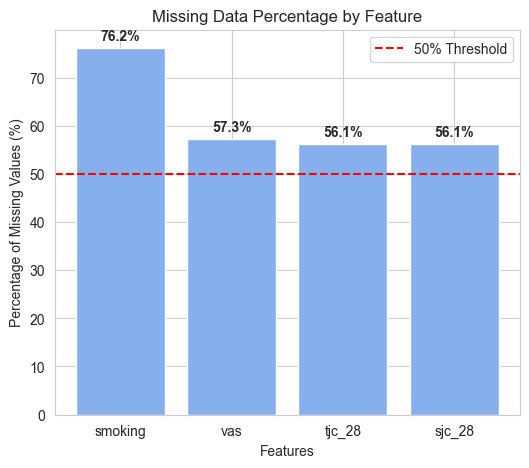

In [90]:
from src.preprocessing import handle_categorical_missing, load_data

df_raw = load_data(file_path)
handle_categorical_missing(df_raw)

missing_percent = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
high_missing = missing_percent[missing_percent > 50]

plt.figure(figsize=(6, 5))
graph = plt.bar(high_missing.index.to_numpy(), high_missing.to_numpy(), color="#85b0ed")

for p in graph:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    plt.text(
        x,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        weight="bold"
    )
plt.axhline(50, color='red', linestyle='--', label='50% Threshold')
plt.title('Missing Data Percentage by Feature')
plt.xlabel('Features')
plt.ylabel('Percentage of Missing Values (%)')
plt.legend()
plt.show()

#### Dataset Overview

In [91]:
df_cleaned.shape

(393, 51)

In [92]:
df_cleaned.head(10)

,patient_id,gender,year_of_diagnosis,rf_status,anti_ccp_status,comorbidities,visit_date,visit_type,crp,crp_upper_limit,...,comorb_gastrointestinal_hepatic,comorb_malignancy,comorb_musculoskeletal,comorb_neurologic_psychiatric,comorb_autoimmune_other,comorbidity_count,csdmard_use,b_ts_dmard_use,steroid_use,treatment_count
0,RA001,1,1997,0,0,"depression,hypothyroidism",2017-12-18,Baseline,0.40,0.5,...,0,0,0,1,0,2,1,1,0,3
1,RA001,1,1997,0,0,"depression,hypothyroidism",2018-03-20,Follow-up,0.40,0.5,...,0,0,0,1,0,2,1,0,0,2
2,RA001,1,1997,0,0,"depression,hypothyroidism",2018-09-25,Follow-up,0.40,0.5,...,0,0,0,1,0,2,0,1,0,1
4,RA002,1,1999,0,0,,2023-10-27,Baseline,0.02,0.5,...,0,0,0,0,0,0,1,1,0,3
5,RA002,1,1999,0,0,,2024-01-30,Follow-up,0.07,0.5,...,0,0,0,0,0,0,1,1,0,2
6,RA002,1,1999,0,0,,2024-04-23,Follow-up,1.90,5.0,...,0,0,0,0,0,0,1,1,0,2
7,RA002,1,1999,0,0,,2024-09-17,Follow-up,0.10,0.5,...,0,0,0,0,0,0,1,1,0,2
9,RA003,0,2005,1,1,transient ischemic attack,2023-09-01,Baseline,0.46,0.5,...,0,0,0,0,0,1,0,0,0,0
11,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-05-16,Baseline,NaN,NaN,...,0,0,0,0,0,1,1,0,1,3
12,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-09-20,Follow-up,6.60,5.0,...,0,0,0,0,0,1,1,0,1,2


In [93]:
df_cleaned.columns.to_list()

['patient_id',
 'gender',
 'year_of_diagnosis',
 'rf_status',
 'anti_ccp_status',
 'comorbidities',
 'visit_date',
 'visit_type',
 'crp',
 'crp_upper_limit',
 'esr',
 'das28_score',
 'csdmard_name',
 'mtx_use',
 'mtx_dose',
 'b_ts_dmard_name',
 'steroid_dose',
 'treatment_decision',
 'switch_reason',
 'flare_event',
 'source',
 'treatment_decision_grouped',
 'birth_year',
 'days_since_last_visit',
 'disease_duration',
 'age_at_visit',
 'das28_change',
 'previous_flare',
 'target_flare_next',
 'crp_missing',
 'esr_missing',
 'crp_normalized',
 'log_crp_normalized',
 'crp_high',
 'esr_high',
 'inflammation_flag',
 'inflammation_score',
 'comorb_cardiovascular',
 'comorb_metabolic_endocrine',
 'comorb_respiratory',
 'comorb_renal_urological',
 'comorb_gastrointestinal_hepatic',
 'comorb_malignancy',
 'comorb_musculoskeletal',
 'comorb_neurologic_psychiatric',
 'comorb_autoimmune_other',
 'comorbidity_count',
 'csdmard_use',
 'b_ts_dmard_use',
 'steroid_use',
 'treatment_count']

In [94]:
df_cleaned.describe().T

,count,mean,min,25%,50%,75%,max,std
gender,393.0,0.760814,0.0,1.0,1.0,1.0,1.0,0.42713
year_of_diagnosis,391.0,2011.450128,1981.0,2005.0,2015.0,2019.0,2025.0,10.467382
rf_status,390.0,0.553846,0.0,0.0,1.0,1.0,1.0,0.497731
anti_ccp_status,390.0,0.674359,0.0,0.0,1.0,1.0,1.0,0.469216
visit_date,393,2021-03-22 21:40:45.801526,2015-03-03 00:00:00,2019-04-08 00:00:00,2021-06-04 00:00:00,2023-05-15 00:00:00,2025-12-02 00:00:00,NaN
crp,326.0,3.377095,0.01,0.2825,0.75,2.9,62.5,7.141311
crp_upper_limit,326.0,2.495859,0.05,0.5,0.5,5.0,7.0,2.44284
esr,361.0,25.293629,2.0,11.0,20.0,35.0,105.0,19.926453
das28_score,248.0,3.404194,1.03,2.415,3.355,4.2,6.8,1.233597
mtx_use,393.0,0.557252,0.0,0.0,1.0,1.0,1.0,0.497345


In [95]:
df_cleaned.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 393 entries, 0 to 497
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   patient_id                       393 non-null    str           
 1   gender                           393 non-null    Int64         
 2   year_of_diagnosis                391 non-null    Int64         
 3   rf_status                        390 non-null    Int64         
 4   anti_ccp_status                  390 non-null    Int64         
 5   comorbidities                    393 non-null    str           
 6   visit_date                       393 non-null    datetime64[us]
 7   visit_type                       393 non-null    str           
 8   crp                              326 non-null    float64       
 9   crp_upper_limit                  326 non-null    float64       
 10  esr                              361 non-null    float64       
 11  das28_sco

#### Missingness

In [96]:
missing_count = df_cleaned.isnull().sum()
missing_percentage = (df_cleaned.isnull().mean() * 100).round(1)

#Summary Table
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
    }).sort_values(by='missing_percentage', ascending=False)

missing_table[missing_table['missing_percentage'] > 0]

,missing_count,missing_percentage
das28_score,145,36.9
das28_change,134,34.1
crp_upper_limit,67,17.0
log_crp_normalized,67,17.0
crp_normalized,67,17.0
crp,67,17.0
esr,32,8.1
rf_status,3,0.8
anti_ccp_status,3,0.8
disease_duration,2,0.5


In [97]:
df_cleaned[df_cleaned["patient_id"] == 'RA085'][['patient_id', 'days_since_last_visit', 'das28_score']]

,patient_id,days_since_last_visit,das28_score
384,RA085,0,4.60
385,RA085,122,4.09
386,RA085,133,3.40
387,RA085,132,4.04
388,RA085,174,3.50
389,RA085,239,3.31
390,RA085,149,3.30
391,RA085,124,3.54
392,RA085,226,NaN
393,RA085,222,NaN


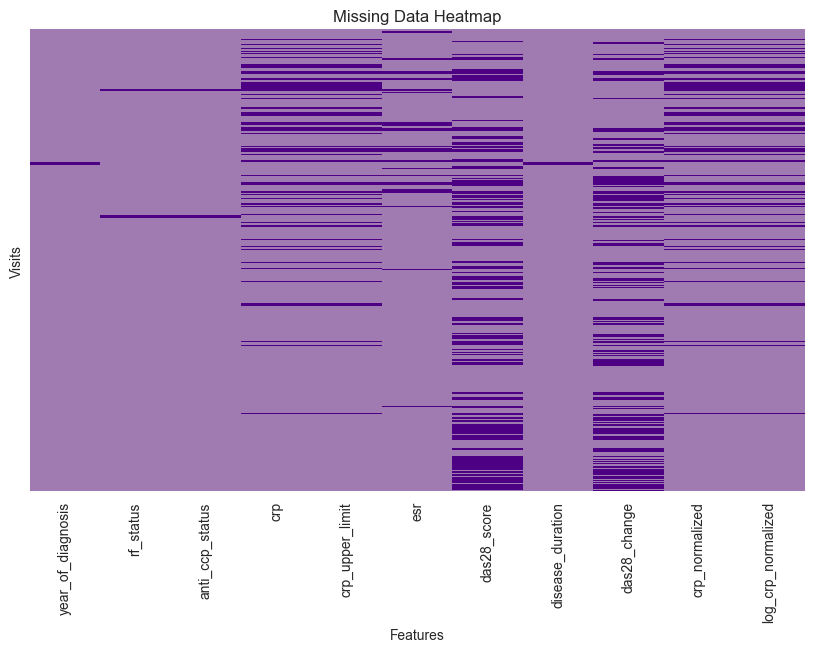

In [98]:
#Missingness Visualization
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#A07BB2FF", "#4e0085"])


#Heatmap of missing values
missing_cols = df_cleaned.columns[df_cleaned.isnull().any()]
plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned[missing_cols].isnull(), cbar=False, cmap=cmap, yticklabels=False)
plt.title('Missing Data Heatmap')
plt.xlabel('Features')
plt.ylabel('Visits')
plt.show()


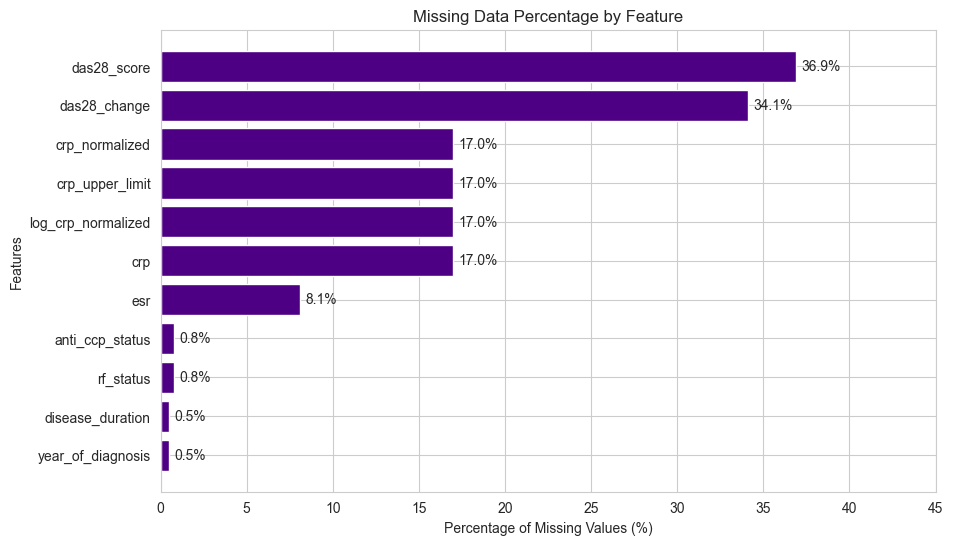

In [99]:
#Barplot of missing values
missing_plot = (missing_table[missing_table['missing_percentage'] > 0]
                .sort_values(by='missing_percentage', ascending=True))

plt.figure(figsize=(10, 6))
graph = plt.barh(missing_plot.index, missing_plot['missing_percentage'], color='#4e0085')

for p in graph:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    plt.text(
        width + 0.3,   
        y,
        f"{width:.1f}%",
        va="center",
        
    )

plt.title('Missing Data Percentage by Feature')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Features')
plt.xlim(0, 45)
plt.show()


In [100]:
crp_counts = pd.crosstab(df_cleaned['crp_missing'], df_cleaned['target_flare_next'], 
            rownames=['CRP missing'], colnames=['Flare next visit'])


crp_percent = pd.crosstab(df_cleaned["crp_missing"], df_cleaned["target_flare_next"], normalize="index", 
            rownames=["CRP missing"], colnames=["Flare next visit"]).round(2)

display(crp_counts)
display(crp_percent)

Flare next visit,0,1
CRP missing,,
0,221,105
1,42,25


Flare next visit,0,1
CRP missing,,
0,0.68,0.32
1,0.63,0.37


In [101]:
esr_counts = pd.crosstab(df_cleaned['esr_missing'], df_cleaned['target_flare_next'], 
            rownames=['ESR missing'], colnames=['Flare next visit'])


esr_percent = pd.crosstab(df_cleaned["esr_missing"], df_cleaned["target_flare_next"], normalize="index", 
            rownames=["ESR missing"], colnames=["Flare next visit"]).round(2)

display(esr_counts)
display(esr_percent)

Flare next visit,0,1
ESR missing,,
0,240,121
1,23,9


Flare next visit,0,1
ESR missing,,
0,0.66,0.34
1,0.72,0.28


In [102]:
df_cleaned['das28_missing'] = df_cleaned['das28_change'].isnull().astype(int)

das28_counts = pd.crosstab(df_cleaned['das28_missing'], df_cleaned['target_flare_next'], 
            rownames=['DAS28 Missing'], colnames=['Flare next visit'])


das28_percent = pd.crosstab(df_cleaned["das28_missing"], df_cleaned["target_flare_next"], normalize="index", 
            rownames=["DAS28 Missing"], colnames=["Flare next visit"]).round(2)

display(das28_counts)
display(das28_percent)

Flare next visit,0,1
DAS28 Missing,,
0,172,87
1,91,43


Flare next visit,0,1
DAS28 Missing,,
0,0.66,0.34
1,0.68,0.32


### Does feature missingness appear to affect the target variable?

<span style="color: green;">**CRP**</span>  
The proportion of next-visit flare was similar between visits with available and missing values.  
- When CRP is present (0) : 41%  
- When CRP is not present (1): 36%  
- Difference: 5%. 


This small difference suggests that CRP missingness is not strongly associated with the outcome and is unlikely to represent highly informative missingness.



<span style="color: cyan;">**ESR**</span>   
For ESR, visits with missing values showed a lower proportion of next-visit flare compared with visits where ESR was available.  
- When ESR is present (0) and available 80/192: 42%  
- When ESR is not present (1) and missing 10/36: 28%  
- Difference: 14%  

This more noticeable difference suggests that ESR missingness may carry some information and may not be completely random, although the number of visits with missing ESR was smaller.
  
<span style="color: purple;">**DAS28 score**</span>   
Because DAS28_score and DAS28_change are highly correlated, only das28_score missingness percentage was evaluated.  
The proportion of next-visit flare was similar between visits with available and missing values.  
- When DAS28 is present (0), and available 55/133: 41%  
- When DAS28 is not present (1) and available 35/95: 37%  
- Difference: 4%   

This small difference suggests that DAS28 score missingness is not strongly associated with the outcome.

### Target Analysis


In [103]:
# Percentages of target variable
df_cleaned["target_flare_next"].value_counts(normalize=True, dropna=False) * 100

target_flare_next
0    66.92112
1    33.07888
Name: proportion, dtype: float64

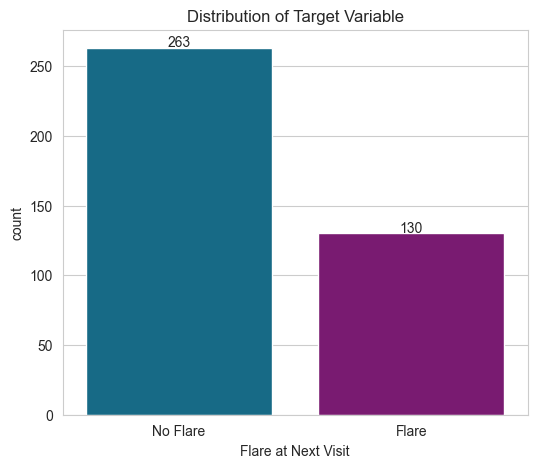

In [104]:
# Counts of target variable
plt.figure(figsize=(6, 5))
graph = sns.countplot(x='target_flare_next', data=df_cleaned, 
                      hue= 'target_flare_next', palette= ["#047398", "#880c7e"], legend=False)
plt.title('Distribution of Target Variable')
plt.xlabel('Flare at Next Visit')
plt.xticks(ticks=[0, 1], labels=['No Flare', 'Flare'])


for p in graph.patches: 
    bar = p
    if isinstance(bar, Rectangle):
        height = bar.get_height()
        graph.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{int(height)}",
        ha='center'      
    )
plt.show()

The target variable 'flare_next_visit' showed imbalance between Flare and no Flare events.

### Visits per patient

In [105]:
#visits per patient
visits_per_patient = df_cleaned.groupby('patient_id').size()

#average visits per patient
visits_per_patient.describe()

count    106.000000
mean       3.707547
std        2.559639
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       15.000000
dtype: float64

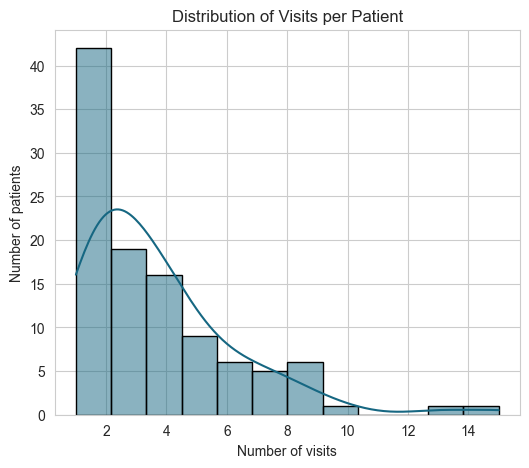

In [106]:
plt.figure(figsize=(6, 5))
sns.histplot(
    x = visits_per_patient,
    bins=12,
    kde=True,
    color="#166782FF",
    edgecolor="black"
)
plt.title('Distribution of Visits per Patient')
plt.xlabel('Number of visits')
plt.ylabel('Number of patients')
plt.show()

The number of visits per patient was examined to better characterize the longitudinal structure of the dataset. A total of **70 patients** were included, with a mean of **3.7 visits per patient** (SD = **2.55**) and a median of **3 visits**. Most patients contributed between **2 and 4 visits**, although follow-up was unequal across the cohort, ranging from **1 to 15 visits**. This pattern is consistent with real-world longitudinal clinical data, where the number of recorded visits varies between patients.

### Univariate Analysis

Continuous variables


In [107]:
df_cleaned['das28_score'].describe()

count    248.000000
mean       3.404194
std        1.233597
min        1.030000
25%        2.415000
50%        3.355000
75%        4.200000
max        6.800000
Name: das28_score, dtype: float64

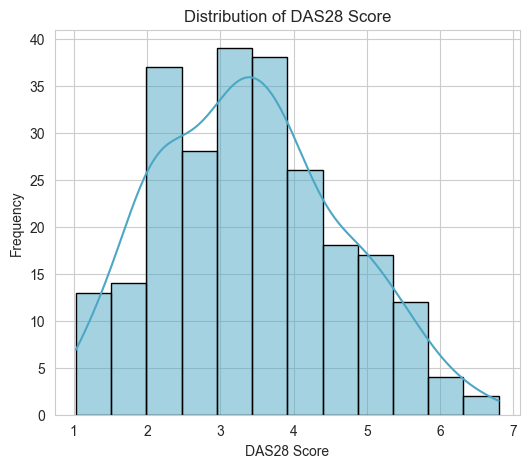

In [108]:
plt.figure(figsize=(6, 5))
sns.histplot(
    data=df_cleaned.dropna(subset=['das28_score']),
    x='das28_score',
    bins=12,
    color="#4CA7C5FF",
    kde=True,
    edgecolor='black'
)
plt.title('Distribution of DAS28 Score')
plt.xlabel('DAS28 Score')
plt.ylabel('Frequency')
plt.show()

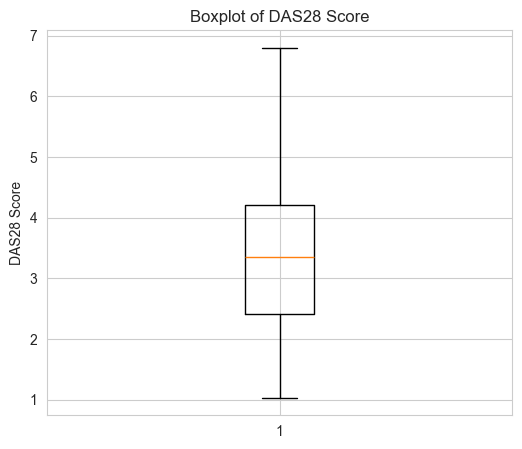

In [109]:
plt.figure(figsize=(6, 5))
plt.boxplot(x=df_cleaned['das28_score'].dropna(), vert=True)
plt.title('Boxplot of DAS28 Score')
plt.ylabel('DAS28 Score')
plt.show()

In [110]:
from scipy.stats import shapiro
shapiro(df_cleaned['das28_score'].dropna())


ShapiroResult(statistic=np.float64(0.9840189502530989), pvalue=np.float64(0.0069769190023927855))

In [111]:
df_cleaned['crp_normalized'].describe()

count    326.000000
mean       1.675178
std        3.294451
min        0.002000
25%        0.261667
50%        0.626667
75%        1.600000
max       32.000000
Name: crp_normalized, dtype: float64

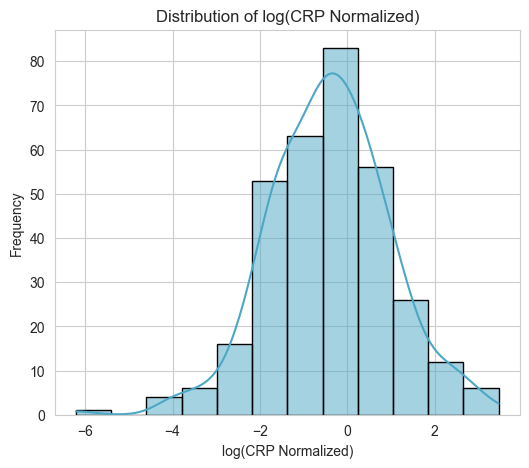

In [112]:
plt.figure(figsize=(6, 5))
sns.histplot(
    data=df_cleaned.dropna(subset=['log_crp_normalized']),
    x='log_crp_normalized',
    bins=12,
    color="#4CA7C5FF",
    kde=True,
    edgecolor='black'
)
plt.title('Distribution of log(CRP Normalized)')
plt.xlabel('log(CRP Normalized)')
plt.ylabel('Frequency')
plt.show()

In [113]:
df_cleaned['log_crp_normalized'].skew()

np.float64(-0.14287081117125647)

In [114]:
from scipy.stats import shapiro

df_transforms = pd.DataFrame({
    'original': df_cleaned['crp_normalized'],
    'sqrt': np.sqrt(df_cleaned['crp_normalized']),
    'cuberoot': np.cbrt(df_cleaned['crp_normalized']),
    'log': np.log(df_cleaned['crp_normalized']),
    'reciprocal': 1 / df_cleaned['crp_normalized']

})

results = {}

for col in df_transforms.columns:
    statistics, p = shapiro(df_transforms[col].dropna())
    results[col] = {
        'transform':col,
        'statistic': statistics,
        'p_value': p
    }

results_df = pd.DataFrame(results).T.sort_values(by='p_value', ascending=False)
results_df


,transform,statistic,p_value
log,log,0.990845,0.040195
cuberoot,cuberoot,0.892328,0.0
sqrt,sqrt,0.785263,0.0
original,original,0.463589,0.0
reciprocal,reciprocal,0.106142,0.0


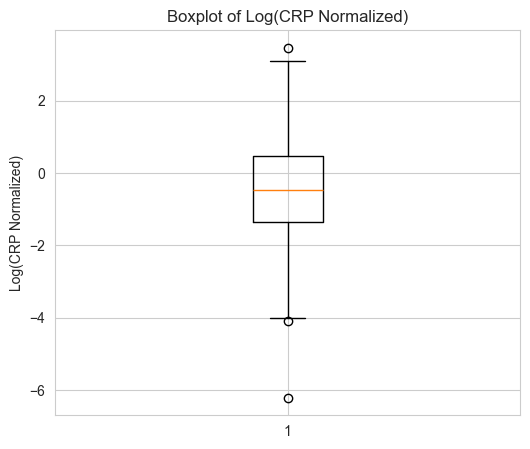

In [115]:
plt.figure(figsize=(6, 5))
plt.boxplot(x=df_cleaned['log_crp_normalized'].dropna(), vert=True)
plt.title('Boxplot of Log(CRP Normalized)')
plt.ylabel('Log(CRP Normalized)')
plt.show()

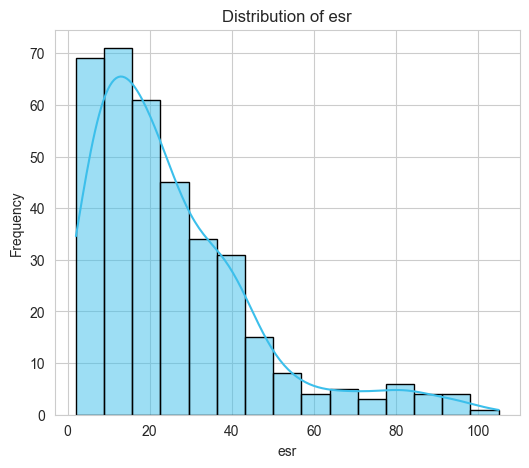

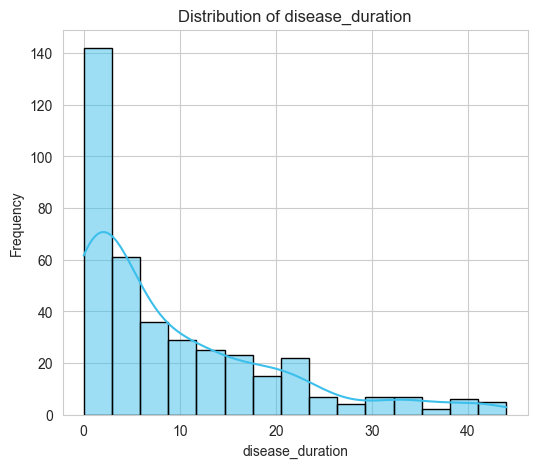

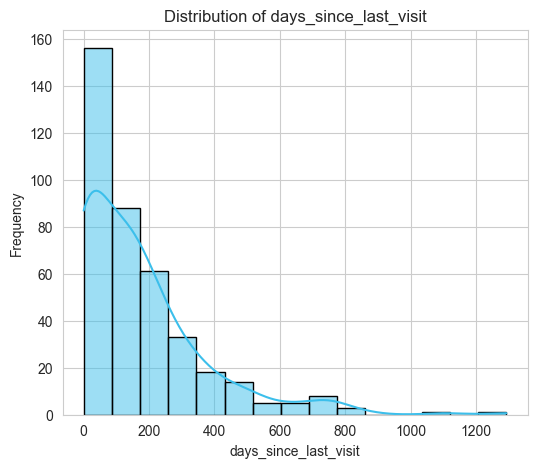

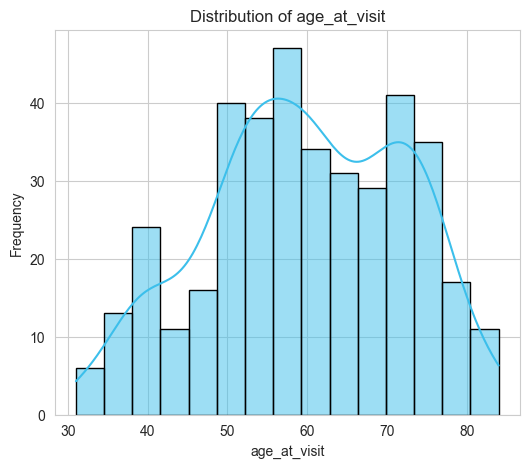

In [116]:
df_cleaned['log_esr'] = np.log(df_cleaned['esr'])
df_cleaned['log_days_since_last_visit'] = np.log1p(df_cleaned['days_since_last_visit'])
df_cleaned['log_disease_duration'] = np.log1p(df_cleaned['disease_duration'])

continuous_variables = [
                'esr',
                'disease_duration',
                'days_since_last_visit', 
                'age_at_visit'
]

for col in continuous_variables:
    plt.figure(figsize=(6, 5))
    sns.histplot(
        data=df_cleaned.dropna(subset=[col]),
        x=col,
        bins=15,
        color="#3CBFEBFF",
        kde=True,
        edgecolor='black'
    )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [117]:
df_cleaned['esr'].skew()

np.float64(1.5404135838202748)

In [118]:
from scipy.stats import shapiro

df_transforms = pd.DataFrame({
    'original': df_cleaned['esr'],
    'sqrt': np.sqrt(df_cleaned['esr']),
    'cuberoot': np.cbrt(df_cleaned['esr']),
    'log': np.log(df_cleaned['esr']),
    'reciprocal': 1 / df_cleaned['esr']

})

results = {}

for col in df_transforms.columns:
    statistics, p = shapiro(df_transforms[col].dropna())
    results[col] = {
        'transform': col,
        'statistic': statistics,
        'p_value': p
    }

results_df_esr = pd.DataFrame(results).T.sort_values(by='p_value', ascending=False)
results_df_esr

,transform,statistic,p_value
log,log,0.98622,0.00164
cuberoot,cuberoot,0.981473,0.000136
sqrt,sqrt,0.962073,0.0
original,original,0.855139,0.0
reciprocal,reciprocal,0.764009,0.0


In [119]:
from scipy.stats import shapiro

for col in continuous_variables:
    shapiro_result = shapiro(df_cleaned[col].dropna())
    print(f"Shapiro-Wilk test for {col}:")
    print(f"  Statistic: {shapiro_result.statistic}")
    print(f"  p-value: {shapiro_result.pvalue}")

Shapiro-Wilk test for esr:
  Statistic: 0.8551393796745937
  p-value: 8.597961352654933e-18
Shapiro-Wilk test for disease_duration:
  Statistic: 0.820998503702601
  p-value: 1.5461695399883134e-20
Shapiro-Wilk test for days_since_last_visit:
  Statistic: 0.8082922883661041
  p-value: 2.949435601281807e-21
Shapiro-Wilk test for age_at_visit:
  Statistic: 0.9799347872586612
  p-value: 2.8392433069536482e-05


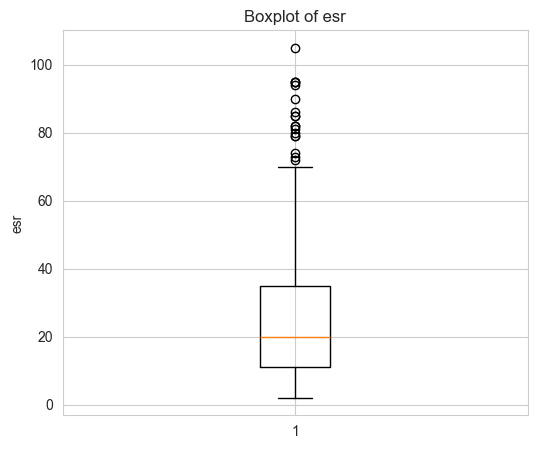

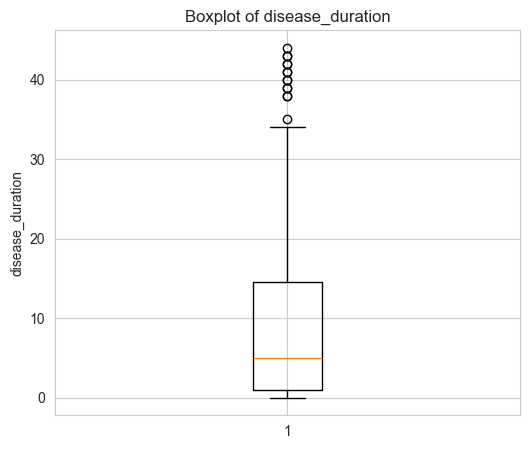

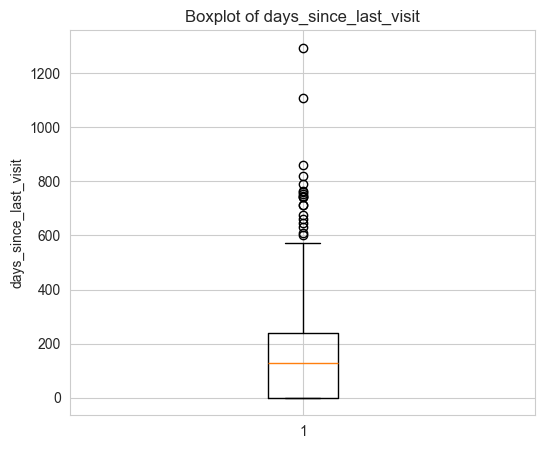

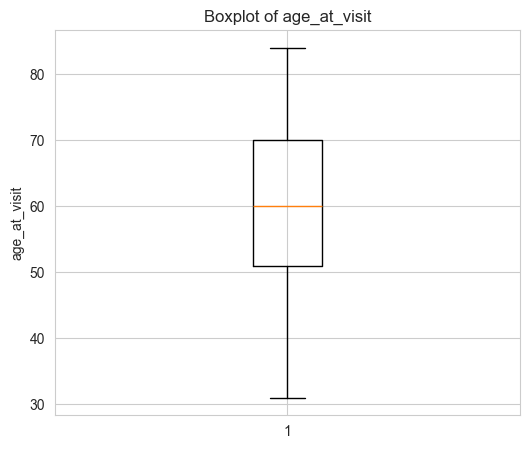

In [120]:
for col in continuous_variables:
    plt.figure(figsize=(6, 5))
    plt.boxplot(x=df_cleaned[col].dropna(), vert=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [121]:
# dose_counts = df_cleaned["mtx_dose"].value_counts().sort_index()
# x_labels = dose_counts.index.astype(str).to_list()
# y_counts = dose_counts.to_numpy(dtype=float)

# plt.figure(figsize=(8,4))
# bars = plt.bar(x_labels, y_counts, color="#5aa9c9")
# plt.title("Distribution of MTX Dose")
# plt.xlabel("MTX Dose")
# plt.ylabel("Count")

# for b in bars: 
#     height = b.get_height()
#     plt.text(
#         b.get_x() + b.get_width()/2,
#         height +1,
#         f'{int(height)}', 
#         ha = 'center'
#     )

# plt.show()

In [122]:
df_cleaned['mtx_dose_category'] = pd.cut(
    df_cleaned['mtx_dose'],
    bins=[-0.1, 0, 10, 20, 25],
    labels=['0 mg', '1-10 mg', '11-20 mg', '21-25 mg']
    )

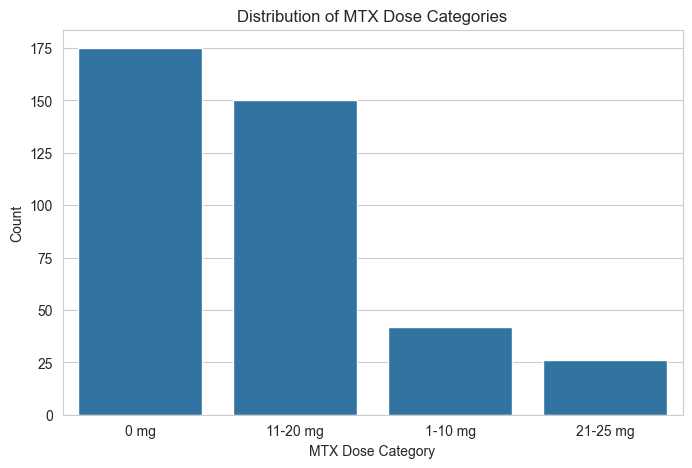

In [123]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_cleaned,
    x="mtx_dose_category",
    order=df_cleaned["mtx_dose_category"].value_counts().index
)
plt.title("Distribution of MTX Dose Categories")
plt.xlabel("MTX Dose Category")
plt.ylabel("Count")
plt.show()

In [124]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df_cleaned["mtx_dose_category"], df_cleaned["target_flare_next"])
chi2, p, dof, expected = chi2_contingency(table)

print(chi2, p)

1.2010809792722639 0.7527450598591002


In [125]:
# dose_counts = df_cleaned["steroid_dose"].value_counts().sort_index()

# x_labels = dose_counts.index.astype(str).tolist()
# y_counts = dose_counts.to_numpy(dtype=float)

# plt.figure(figsize=(8, 4))
# bars = plt.bar(x_labels, y_counts, color="#5aa9c9")

# plt.title("Distribution of Steroid Dose")
# plt.xlabel("Steroid Dose")
# plt.ylabel("Count")

# for b in bars:
#     h = b.get_height()
#     plt.text(b.get_x() + b.get_width() / 2,
#     h + 0.5,
#     f"{int(h)}",
#     ha="center")

# plt.show()

<Axes: xlabel='steroid_dose_category', ylabel='count'>

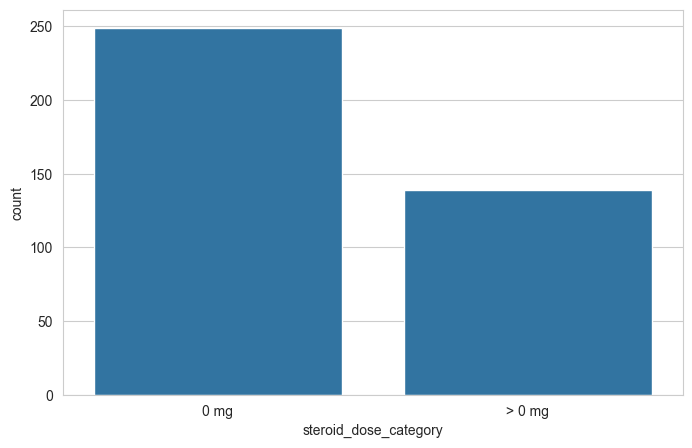

In [126]:
df_cleaned['steroid_dose_category'] = pd.cut(
    df_cleaned['steroid_dose'],
    bins=[-0.1, 1, 15],
    labels=['0 mg', '> 0 mg']
    )

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_cleaned,
    x="steroid_dose_category",
    order=df_cleaned["steroid_dose_category"].value_counts().index
)

In [127]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df_cleaned["steroid_dose_category"], df_cleaned["target_flare_next"])
chi2, p, dof, expected = chi2_contingency(table)

print(chi2, p)

1.6155577623165611 0.20371230839799745


Categorical variables

In [128]:
df_cleaned['gender'].value_counts()

gender
1    299
0     94
Name: count, dtype: Int64

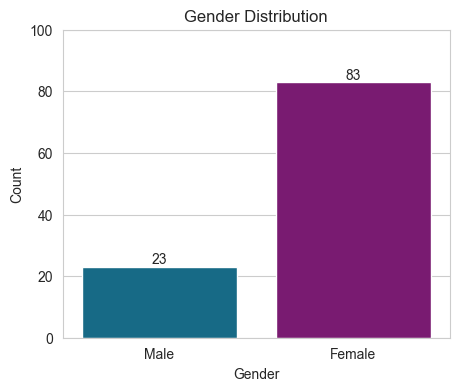

In [129]:
patients_gender = df_cleaned[['patient_id', 'gender']].drop_duplicates(subset='patient_id')

plt.figure(figsize=(5, 4))
graph = sns.countplot(x='gender', data=patients_gender, hue = 'gender', palette= ["#047398", "#880c7e"], legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.ylim(0, 100)
plt.xticks(ticks=[0,1], labels= ['Male', 'Female'] )

for p in graph.patches:
    bar = p
    if isinstance(bar, Rectangle):
        height = bar.get_height()
        graph.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{int(height)}",
            ha='center'      
        )
    
plt.show()

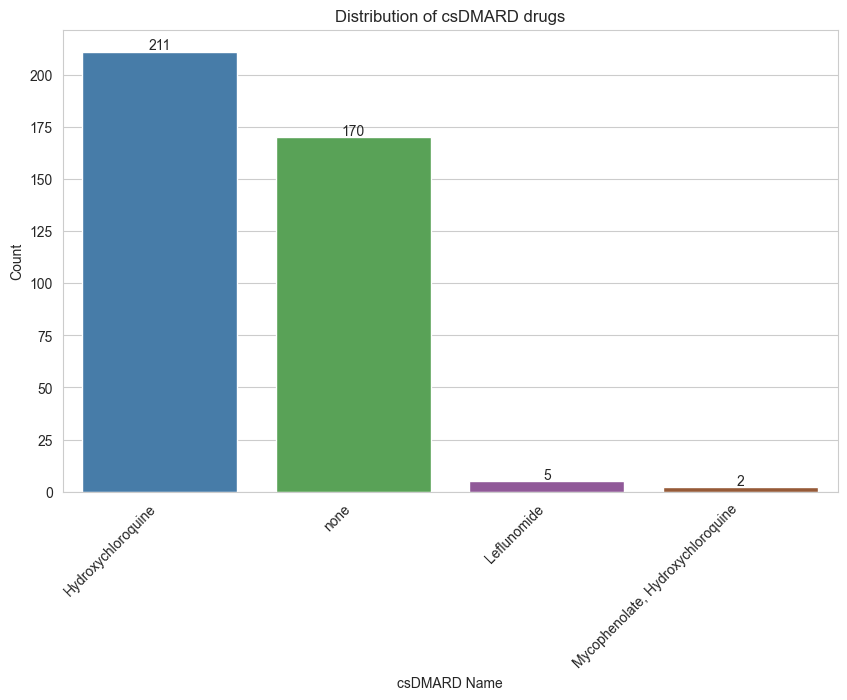

In [130]:
drug_order = df_cleaned["csdmard_name"].value_counts(dropna=False).head(4).index
plt.figure(figsize=(10, 6))
graph = sns.countplot(x='csdmard_name', data=df_cleaned, order= drug_order, hue='csdmard_name', palette= sns.color_palette("Set1"), legend=False)
plt.title('Distribution of csDMARD drugs')
plt.xlabel('csDMARD Name')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')

for p in graph.patches:
    bar = p
    if isinstance(bar, Rectangle):
        height = bar.get_height()
        graph.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{int(height)}",
            ha='center'      
        )
plt.show()

C:\Users\konna\AppData\Local\Temp\ipykernel_30820\2720223999.py:4: UserWarning: The palette list has more values (20) than needed (11), which may not be intended.
  graph = sns.countplot(


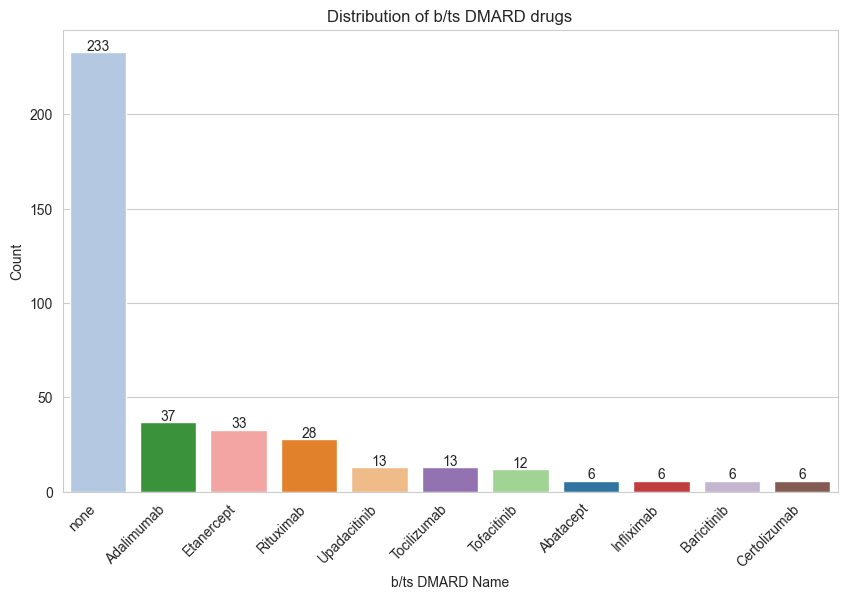

In [131]:
drug_order = df_cleaned["b_ts_dmard_name"].value_counts(dropna=False).index

plt.figure(figsize=(10, 6))
graph = sns.countplot(
    x='b_ts_dmard_name',
    data=df_cleaned, order= drug_order,
    hue='b_ts_dmard_name', 
    palette= sns.color_palette('tab20'), 
    legend=False)

plt.title('Distribution of b/ts DMARD drugs')
plt.xlabel('b/ts DMARD Name')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')

for p in graph.patches:
    bar = p
    if isinstance(bar, Rectangle):
        height = bar.get_height()
        graph.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{int(height)}",
            ha='center'      
        )
plt.show()

In [132]:
comorb_cols = [
    'comorb_cardiovascular', 
    'comorb_metabolic_endocrine', 
    'comorb_respiratory', 
    'comorb_renal_urological',
    'comorb_gastrointestinal_hepatic',
    'comorb_malignancy',
    'comorb_musculoskeletal',
    'comorb_neurologic_psychiatric',
    'comorb_autoimmune_other'
]

comorb_label_map = {
    "comorb_cardiovascular": "Cardiovascular",
    "comorb_metabolic_endocrine": "Metabolic / Endocrine",
    "comorb_respiratory": "Respiratory",
    "comorb_renal_urological": "Renal / Urological",
    "comorb_gastrointestinal_hepatic": "Gastrointestinal / Hepatic",
    "comorb_malignancy": "Malignancy",
    "comorb_musculoskeletal": "Musculoskeletal",
    "comorb_neurologic_psychiatric": "Neurologic / Psychiatric",
    "comorb_autoimmune_other": "Autoimmune / Other"
}


patient_comorb = df_cleaned.groupby('patient_id')[comorb_cols].max()

comorb_counts = patient_comorb.sum().sort_values(ascending = False)

n_patients = patient_comorb.shape[0]
comorb_percent = (comorb_counts / n_patients * 100)

comorb_percent_named = comorb_percent.rename(index=comorb_label_map)
comorb_counts_named = comorb_counts.rename(index=comorb_label_map)


In [182]:
for col in comorb_cols:
    print(f"\n{'='*50}")
    print(comorb_label_map[col])
    print(
        pd.crosstab(
            df_cleaned[col],
            df_cleaned['target_flare_next'],
            rownames=[comorb_label_map[col]],
            colnames=['Flare at Next Visit'],
            normalize='index'
        ).round(2)
    )


Cardiovascular
Flare at Next Visit     0     1
Cardiovascular                 
0                    0.70  0.30
1                    0.62  0.38

Metabolic / Endocrine
Flare at Next Visit       0     1
Metabolic / Endocrine            
0                      0.64  0.36
1                      0.72  0.28

Respiratory
Flare at Next Visit     0     1
Respiratory                    
0                    0.66  0.34
1                    0.73  0.27

Renal / Urological
Flare at Next Visit     0     1
Renal / Urological             
0                    0.67  0.33
1                    0.68  0.32

Gastrointestinal / Hepatic
Flare at Next Visit            0     1
Gastrointestinal / Hepatic            
0                           0.66  0.34
1                           0.70  0.30

Malignancy
Flare at Next Visit     0     1
Malignancy                     
0                    0.66  0.34
1                    0.92  0.08

Musculoskeletal
Flare at Next Visit    0    1
Musculoskeletal              
0      

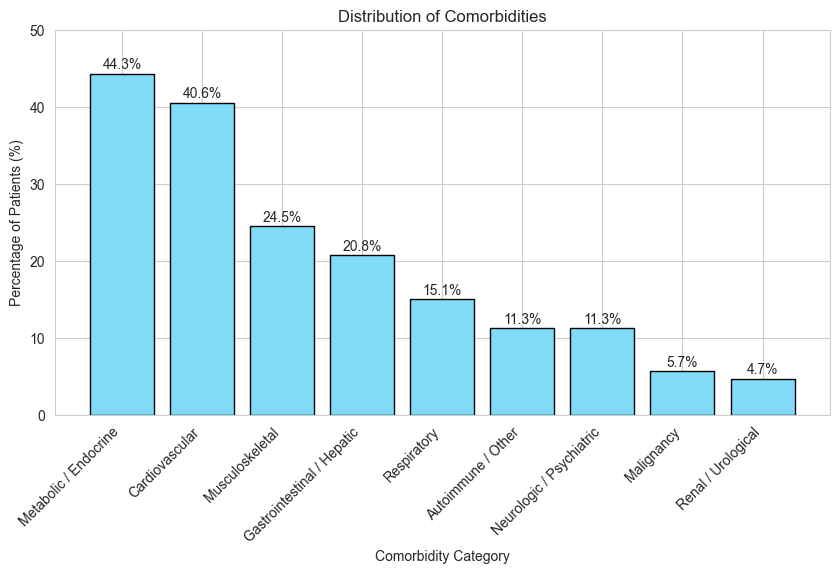

In [133]:
x_labels = comorb_percent_named.index.astype(str).to_list()
y_percent = comorb_percent_named.to_numpy(dtype=float)

plt.figure(figsize=(10, 5))
graph = plt.bar(
    x_labels,
    y_percent,
    color="#80DBF9FF",
    edgecolor="black"
)
plt.title("Distribution of Comorbidities")
plt.xlabel("Comorbidity Category")
plt.ylabel("Percentage of Patients (%)")
plt.ylim(0, 50)
plt.xticks(rotation=45, ha="right")

for p, pct in zip(graph, y_percent): 
    height = p.get_height()
    plt.text(
        p.get_x() + p.get_width() / 2,
        height + 0.2,
        f"{pct:.1f}%",
        ha='center', 
        va='bottom'      
    )
plt.show()

In [134]:
df_cleaned['treatment_decision_grouped'].value_counts(normalize=True, dropna=False) * 100


treatment_decision_grouped
escalation_or_switch    31.552163
no_decision             26.972010
stable                  26.717557
tapering_or_stop        14.758270
Name: proportion, dtype: float64

In [135]:
df_cleaned['switch_reason'].value_counts(normalize=True, dropna=False) * 100

switch_reason
no_switch             92.111959
Inefficacy             7.124682
Adverse event          0.254453
Remission              0.254453
Patient preference     0.254453
Name: proportion, dtype: float64

### Bivariate Analysis
Continuous variables

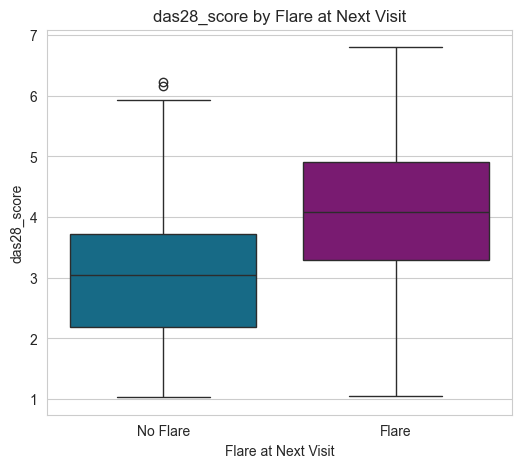

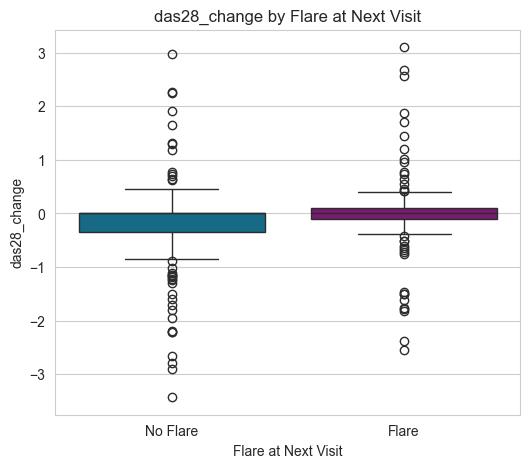

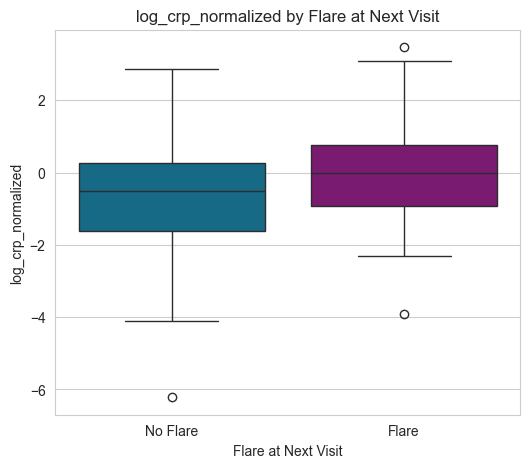

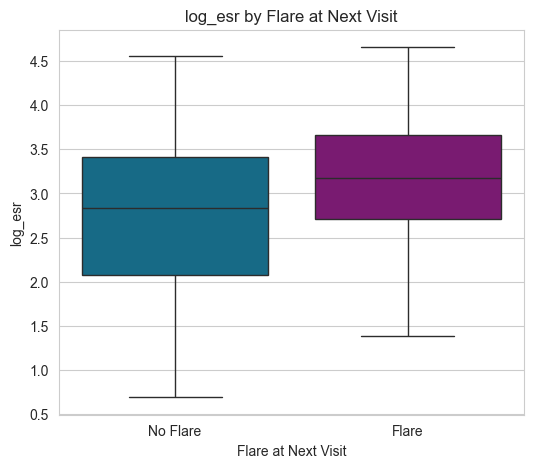

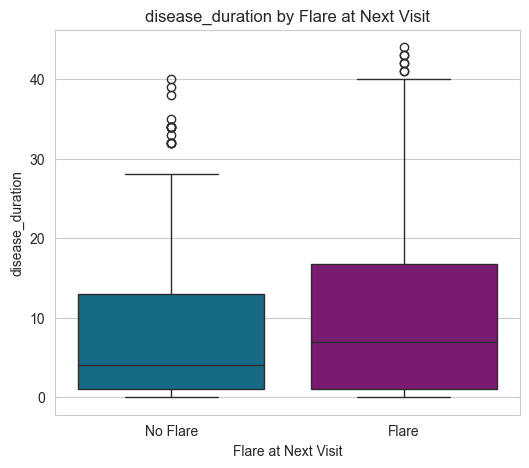

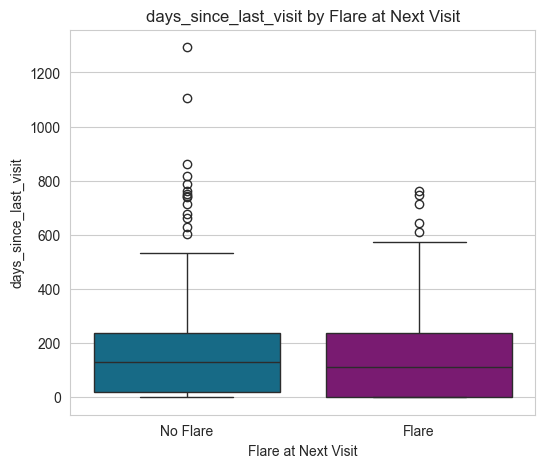

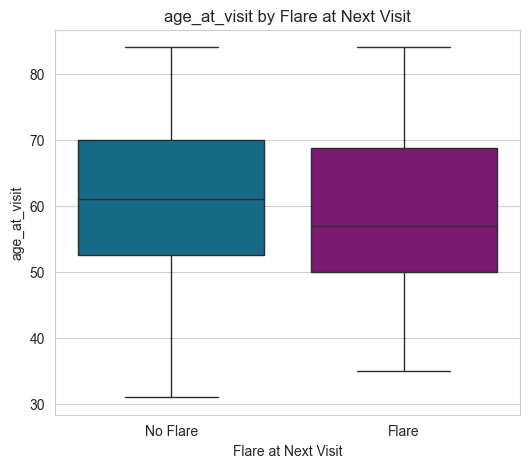

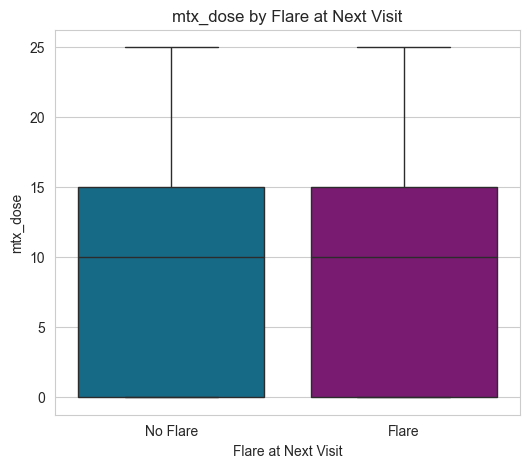

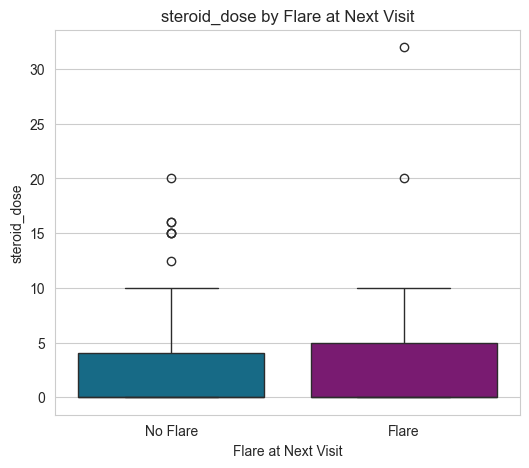

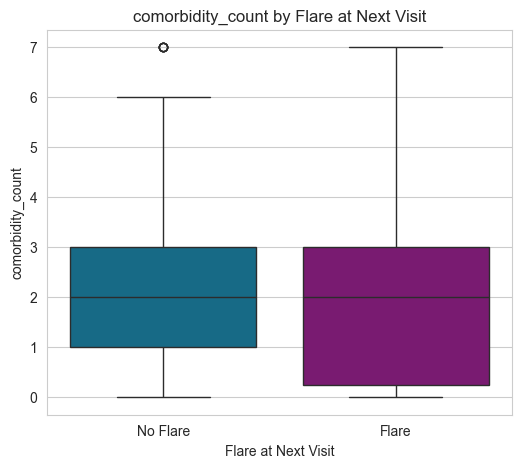

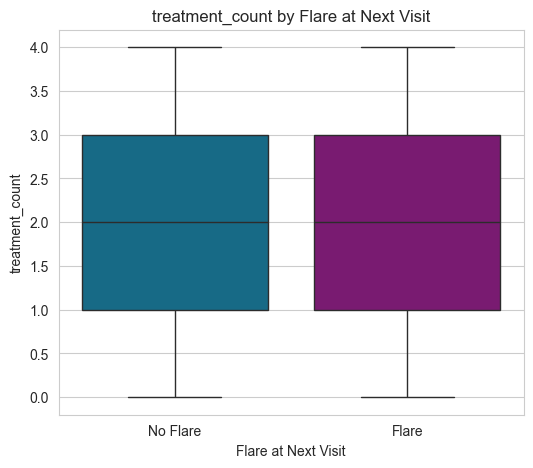

In [136]:
continuous_cols = [
    'das28_score', 'das28_change', 'log_crp_normalized', 'log_esr',
    'disease_duration', 'days_since_last_visit',
    'age_at_visit', 'mtx_dose', 'steroid_dose', 
    'comorbidity_count', 'treatment_count'
    ]

for col in continuous_cols:
    plt.figure(figsize=(6,5))
    sns.boxplot(
        data = df_cleaned, x='target_flare_next',
        y=col, hue='target_flare_next', 
        palette=["#047398", "#880c7e"], legend=False)
    plt.title(f'{col} by Flare at Next Visit')
    plt.xlabel('Flare at Next Visit')
    plt.ylabel(col)
    plt.xticks(ticks=[0,1], labels=['No Flare', 'Flare'])
    plt.show()

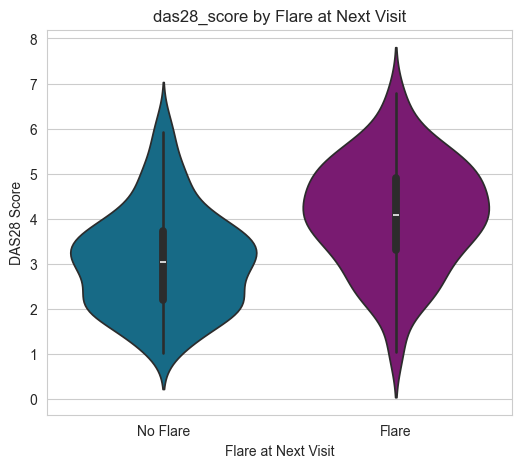

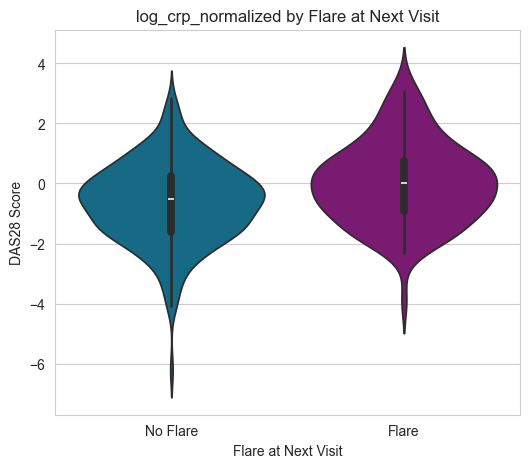

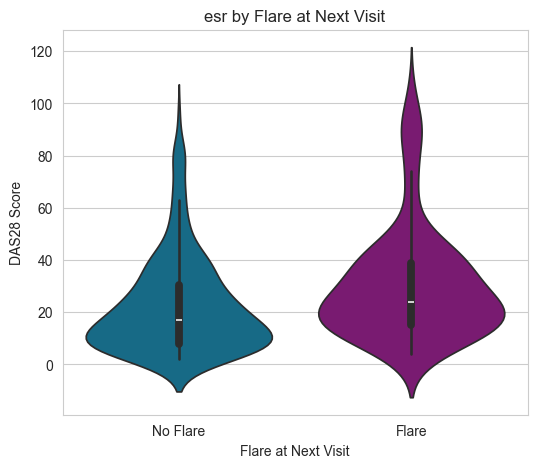

In [137]:
cont_cols = ['das28_score', 'log_crp_normalized', 'esr']

for col in cont_cols:
    plt.figure(figsize=(6, 5))
    sns.violinplot(data=df_cleaned, x="target_flare_next", y=col, hue='target_flare_next', palette=["#047398", "#880c7e"], legend=False)
    plt.title(f'{col} by Flare at Next Visit')
    plt.xlabel('Flare at Next Visit')
    plt.ylabel('DAS28 Score')
    plt.xticks(ticks=[0, 1], labels=['No Flare', 'Flare'])
    plt.show()

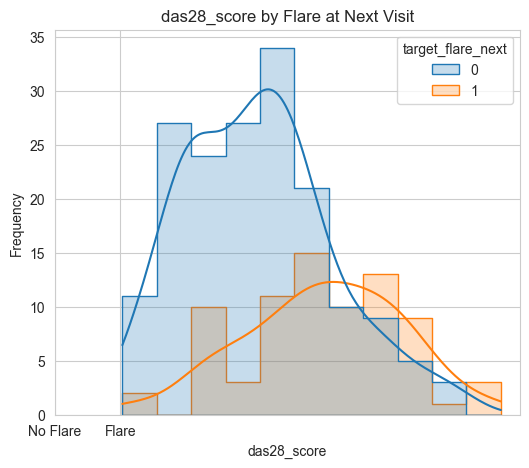

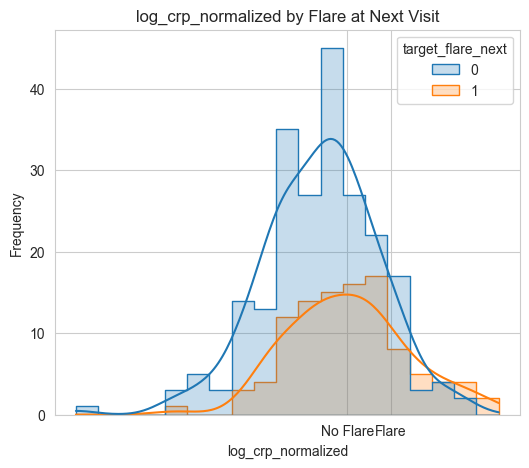

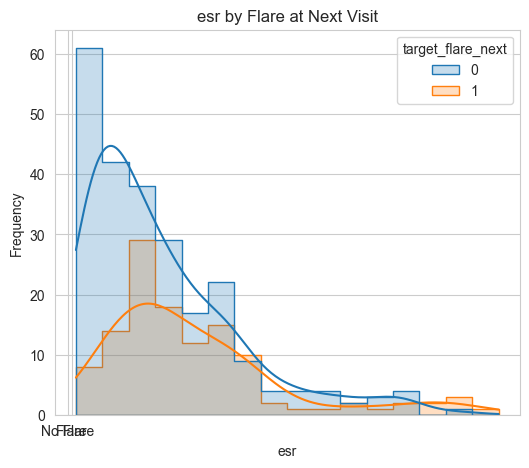

In [138]:

for col in cont_cols:
    plt.figure(figsize=(6, 5))
    sns.histplot(data=df_cleaned, x=col, hue="target_flare_next", kde=True, element="step")
    plt.title(f'{col} by Flare at Next Visit')
    plt.xlabel(f'{col}')
    plt.ylabel('Frequency')
    plt.xticks(ticks=[0, 1], labels=['No Flare', 'Flare'])
    plt.show()

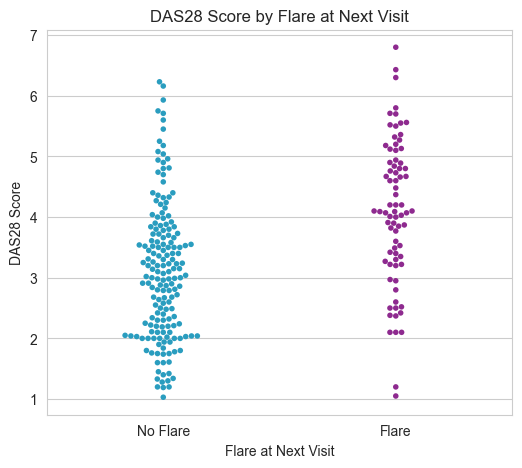

In [139]:
plt.figure(figsize=(6, 5))
sns.swarmplot(
    data=df_cleaned,
    x="target_flare_next",
    y="das28_score",
    hue="target_flare_next",
    palette=["#2A9DBF", "#8E2A8F"],
    legend=False,
    size=4
)
plt.title("DAS28 Score by Flare at Next Visit")
plt.xlabel("Flare at Next Visit")
plt.ylabel("DAS28 Score")
plt.xticks(ticks=[0, 1], labels=["No Flare", "Flare"])
plt.show()

Categorical variables



In [140]:
prev_flare = pd.crosstab(
    df_cleaned['previous_flare'],
    df_cleaned['target_flare_next'],
    rownames=['Previous Flare'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)
prev_flare

Flare at Next Visit,0,1
Previous Flare,,
0,0.71,0.29
1,0.59,0.41


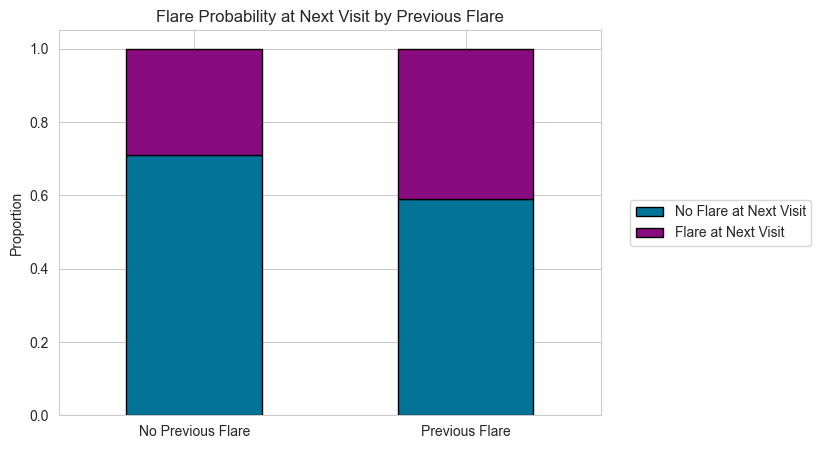

In [141]:
prev_flare.index = prev_flare.index = ["No Previous Flare", "Previous Flare"]
prev_flare.columns = ['No Flare at Next Visit', 'Flare at Next Visit']

prev_flare.plot(kind='bar', stacked=True, figsize=(7,5), color=['#047398', '#880c7e'], edgecolor='black')
plt.title('Flare Probability at Next Visit by Previous Flare')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

In [142]:
pd.crosstab(
    df_cleaned['gender'],
    df_cleaned['target_flare_next'],
    rownames=['Gender'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Gender,,
0,0.69,0.31
1,0.66,0.34


In [143]:
pd.crosstab(
    df_cleaned['rf_status'],
    df_cleaned['target_flare_next'],
    rownames=['RF Status'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
RF Status,,
0,0.68,0.32
1,0.66,0.34


In [144]:
pd.crosstab(
    df_cleaned['anti_ccp_status'],
    df_cleaned['target_flare_next'],
    rownames=['Anti-CCP Status'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Anti-CCP Status,,
0,0.64,0.36
1,0.69,0.31


In [145]:
mtx_use = pd.crosstab(
    df_cleaned['mtx_use'],
    df_cleaned['target_flare_next'],
    rownames=['MTX Use'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)
mtx_use

Flare at Next Visit,0,1
MTX Use,,
0,0.68,0.32
1,0.66,0.34


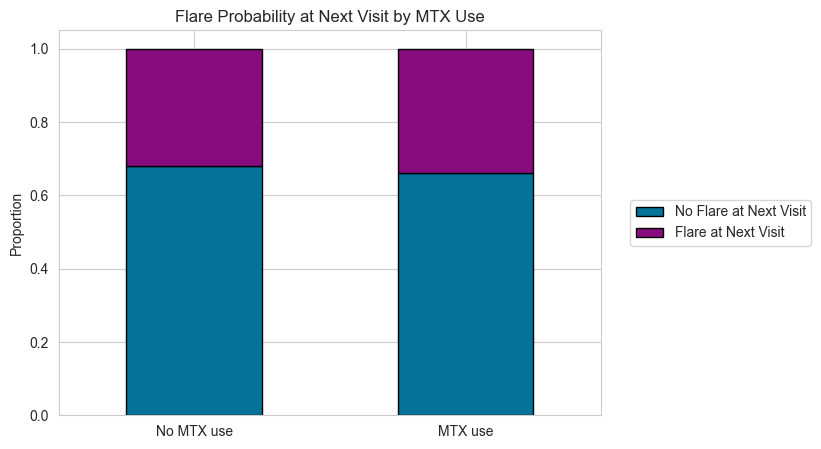

In [146]:
mtx_use.index = mtx_use.index = ["No MTX use", "MTX use"]
mtx_use.columns = ['No Flare at Next Visit', 'Flare at Next Visit']

mtx_use.plot(kind='bar', stacked=True, figsize=(7,5), color=['#047398', '#880c7e'], edgecolor='black')
plt.title('Flare Probability at Next Visit by MTX Use')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

In [147]:
steroid_dose = pd.crosstab(
    df_cleaned['steroid_use'],
    df_cleaned['target_flare_next'],
    rownames=['Steroid Use'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)
steroid_dose

Flare at Next Visit,0,1
Steroid Use,,
0,0.69,0.31
1,0.64,0.36


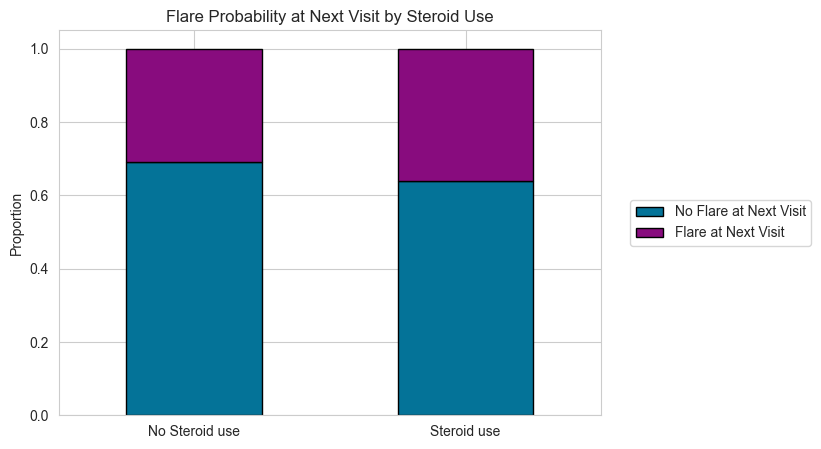

In [148]:
steroid_dose.index = steroid_dose.index = ["No Steroid use", "Steroid use"]
steroid_dose.columns = ['No Flare at Next Visit', 'Flare at Next Visit']
steroid_dose.plot(kind='bar', stacked=True, figsize=(7,5), color=['#047398', '#880c7e'], edgecolor='black')
plt.title('Flare Probability at Next Visit by Steroid Use')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

In [149]:
pd.crosstab(df_cleaned["steroid_dose_category"],
            df_cleaned["target_flare_next"],
            rownames=["Steroid Dose Category"],
            colnames=["Flare at Next Visit"],
            normalize="index").round(2)

Flare at Next Visit,0,1
Steroid Dose Category,,
0 mg,0.69,0.31
> 0 mg,0.63,0.37


In [150]:
pd.crosstab(
    df_cleaned['csdmard_use'],
    df_cleaned['target_flare_next'],
    rownames=['csDMARD Use'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
csDMARD Use,,
0,0.62,0.38
1,0.71,0.29


In [151]:
pd.crosstab(
    df_cleaned['b_ts_dmard_use'],
    df_cleaned['target_flare_next'],
    rownames=['b/ts DMARD Use'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
b/ts DMARD Use,,
0,0.67,0.33
1,0.67,0.33


In [152]:
infl_flag = pd.crosstab(
    df_cleaned['inflammation_flag'],
    df_cleaned['target_flare_next'],
    rownames=['Inflammation Flag'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)
infl_flag

Flare at Next Visit,0,1
Inflammation Flag,,
0,0.75,0.25
1,0.59,0.41


In [153]:
pd.crosstab(
    df_cleaned['crp_high'],
    df_cleaned['target_flare_next'],
    rownames=['CRP High'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
CRP High,,
False,0.71,0.29
True,0.58,0.42


In [154]:
pd.crosstab(
    df_cleaned['esr_high'],
    df_cleaned['target_flare_next'],
    rownames=['ESR High'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
ESR High,,
False,0.74,0.26
True,0.58,0.42


In [155]:
pd.crosstab(
    df_cleaned['inflammation_score'],
    df_cleaned['target_flare_next'],
    rownames=['Inflammation Score'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Inflammation Score,,
0,0.75,0.25
1,0.62,0.38
2,0.55,0.45


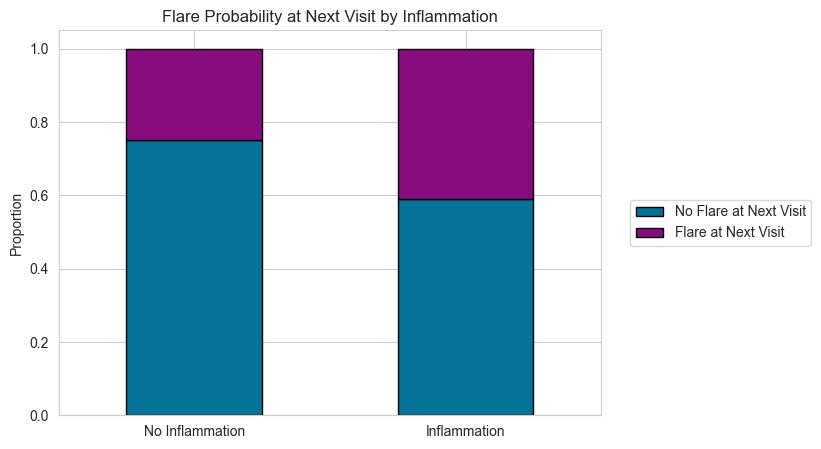

In [156]:
infl_flag.index = infl_flag.index = ["No Inflammation", "Inflammation"]
infl_flag.columns = ['No Flare at Next Visit', 'Flare at Next Visit']
infl_flag.plot(kind='bar', stacked=True, figsize=(7,5), color=['#047398', '#880c7e'], edgecolor='black')
plt.title('Flare Probability at Next Visit by Inflammation')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()


In [157]:
pd.crosstab(
    df_cleaned['treatment_decision_grouped'],
    df_cleaned['target_flare_next'],
    rownames=['Treatment Decision'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Treatment Decision,,
escalation_or_switch,0.66,0.34
no_decision,0.61,0.39
stable,0.73,0.27
tapering_or_stop,0.67,0.33


In [158]:
df_cleaned['days_since_last_visit_bin'] = pd.cut(
    df_cleaned['days_since_last_visit'],
    bins=[0, 30, 90, 180, 365, 1000],
    include_lowest=True
)

pd.crosstab(
    df_cleaned['days_since_last_visit_bin'],
    df_cleaned['target_flare_next'],
    rownames=['Days Since Last Visit'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Days Since Last Visit,,
"(-0.001, 30.0]",0.62,0.38
"(30.0, 90.0]",0.70,0.30
"(90.0, 180.0]",0.67,0.33
"(180.0, 365.0]",0.70,0.30
"(365.0, 1000.0]",0.67,0.33


In [159]:
df_cleaned['days_since_last_visit_bin'].value_counts(dropna=True, sort=False)

days_since_last_visit_bin
(-0.001, 30.0]     114
(30.0, 90.0]        46
(90.0, 180.0]       88
(180.0, 365.0]      94
(365.0, 1000.0]     49
Name: count, dtype: int64

In [160]:
df_cleaned['baseline_visit'] = (df_cleaned['visit_type'] == 'Baseline').astype(int)
pd.crosstab(
    df_cleaned['visit_type'],
    df_cleaned['target_flare_next'],
    rownames=['Baseline Visit'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Baseline Visit,,
Baseline,0.61,0.39
Follow-up,0.69,0.31


In [161]:
df_cleaned["visit_gap_category"] = pd.cut(
    df_cleaned["days_since_last_visit"],
    bins=[-1, 90, 180, 365, np.inf],
    labels=["short", "medium", "long", "very_long"]
)

df_cleaned["long_gap"] = (df_cleaned["days_since_last_visit"] > 180).astype(int)

In [162]:
pd.crosstab(
    df_cleaned["visit_gap_category"],
    df_cleaned["target_flare_next"],
    rownames=["Visit Gap Category"],
    colnames=["Flare at Next Visit"],
    normalize="index").round(2)

Flare at Next Visit,0,1
Visit Gap Category,,
short,0.64,0.36
medium,0.67,0.33
long,0.70,0.30
very_long,0.69,0.31


In [163]:
pd.crosstab(
    df_cleaned["long_gap"],
    df_cleaned["target_flare_next"],
    rownames=["Long Gap"],
    colnames=["Flare at Next Visit"],
    normalize="index"
).round(2)


Flare at Next Visit,0,1
Long Gap,,
0,0.65,0.35
1,0.70,0.30


In [164]:
df_cleaned['age_bins'] =pd.cut(df_cleaned['age_at_visit'], bins=5)
pd.crosstab(
    df_cleaned['age_bins'],
    df_cleaned['target_flare_next'],
    rownames=['Age Group'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Age Group,,
"(30.947, 41.6]",0.67,0.33
"(41.6, 52.2]",0.55,0.45
"(52.2, 62.8]",0.68,0.32
"(62.8, 73.4]",0.78,0.22
"(73.4, 84.0]",0.59,0.41


In [180]:
pd.crosstab(
    df_cleaned['source'],
    df_cleaned['target_flare_next'],
    rownames=['Data Source'],
    colnames=['Flare at Next Visit'],
    normalize='index'
).round(2)

Flare at Next Visit,0,1
Data Source,,
Doctor,0.73,0.27
Hospital,0.60,0.40


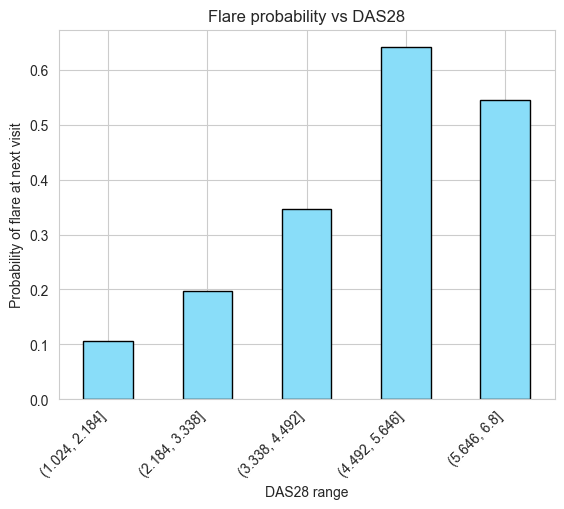

In [165]:
from turtle import color


df_cleaned['das28_bin'] = pd.cut(df_cleaned['das28_score'], bins=5)
flare_rate = df_cleaned.groupby('das28_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar', color="#89DDF9FF", edgecolor='black')

plt.title("Flare probability vs DAS28")
plt.ylabel("Probability of flare at next visit")
plt.xlabel("DAS28 range")
plt.xticks(rotation=45, ha='right')
plt.show()


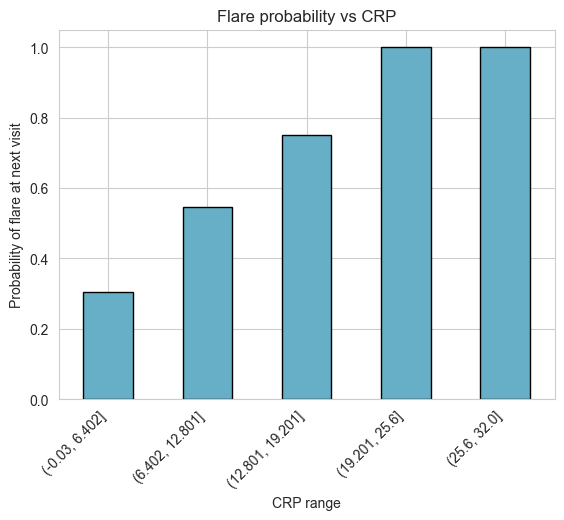

In [166]:
df_cleaned['crp_bin'] = pd.cut(df_cleaned['crp_normalized'], bins=5)
flare_rate = df_cleaned.groupby('crp_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar', color="#67AFC6FF", edgecolor='black')

plt.title("Flare probability vs CRP")
plt.ylabel("Probability of flare at next visit")
plt.xlabel("CRP range")
plt.xticks(rotation=45, ha='right')
plt.show()

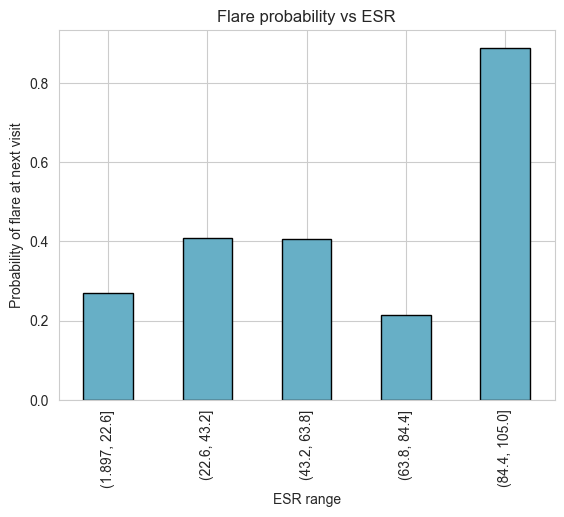

In [167]:
df_cleaned['esr_bin'] = pd.cut(df_cleaned['esr'], bins=5)
flare_rate = df_cleaned.groupby('esr_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar', color="#67AFC6FF", edgecolor='black')

plt.ylabel("Probability of flare at next visit")
plt.xlabel("ESR range")
plt.title("Flare probability vs ESR")
plt.show()

### Correlation matrix

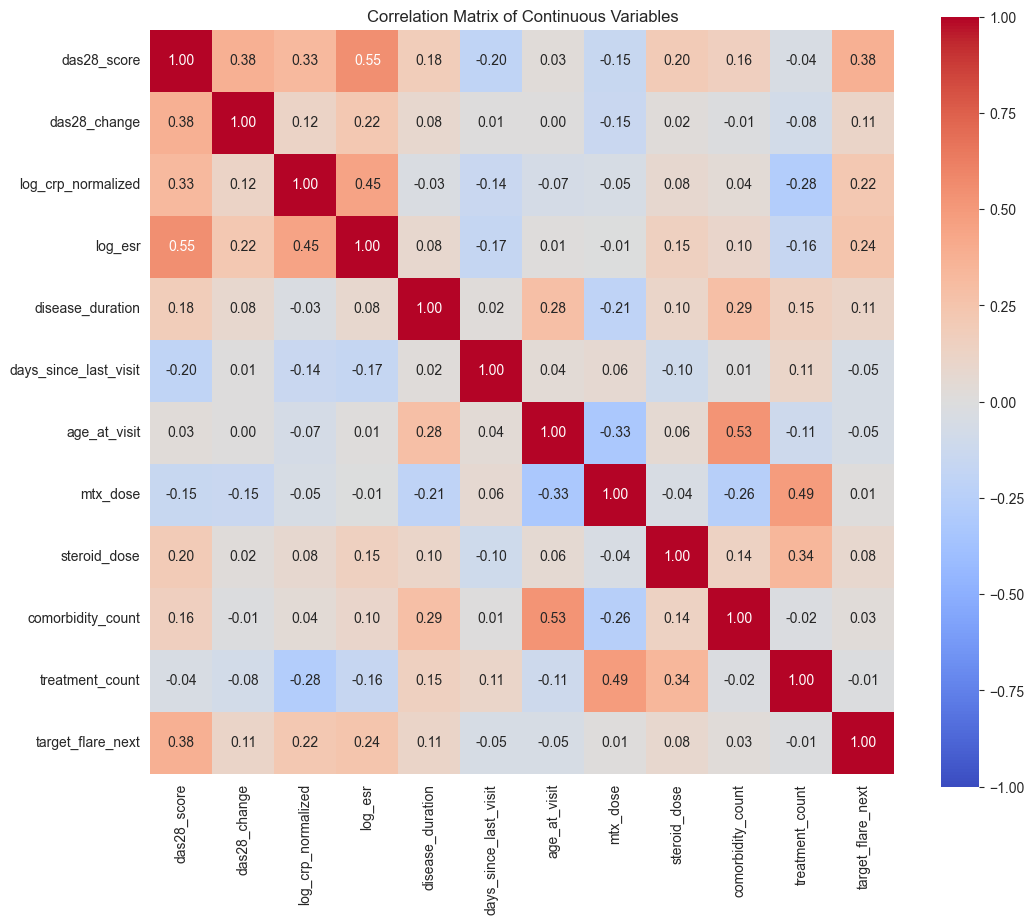

In [168]:

correlation_columns = [
    'das28_score', 'das28_change', 'log_crp_normalized', 'log_esr', 
    'disease_duration', 'days_since_last_visit',
    'age_at_visit', 'mtx_dose', 'steroid_dose', 
    'comorbidity_count', 'treatment_count',
    'target_flare_next'
    ]

corr_matrix = df_cleaned[correlation_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    vmin=-1, vmax=1, center=0,
    cmap='coolwarm', annot=True, fmt=".2f",
    square=True
)
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

Correlation between categorical variables
Crammer's V

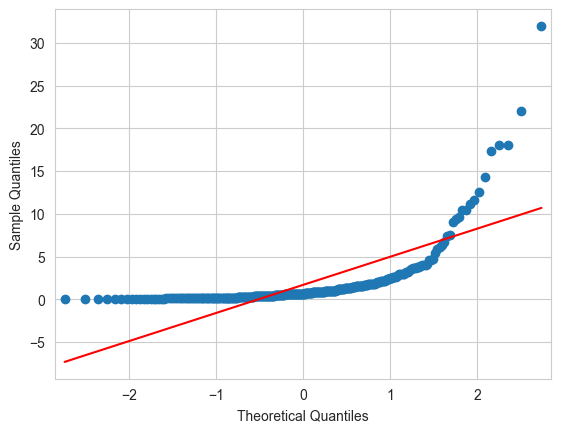

In [169]:
import statsmodels.api as sm
import pylab as py

sm.qqplot(df_cleaned['crp_normalized'].dropna(), line='s')
py.show()

In [179]:
from matplotlib.pylab import normal


pairs = [
    ('esr_high', 'crp_high'),
    ('esr_high', 'inflammation_flag'),
    ('crp_high', 'inflammation_flag'),
    ('esr_high', 'inflammation_score'),
    ('crp_high', 'inflammation_score'),
    ('inflammation_flag', 'inflammation_score')
]

for a, b in pairs:
    print(f"\n{'='*50}")
    print(f"{a} vs {b}")
    print(pd.crosstab(df_cleaned[a], df_cleaned[b], normalize='index').round(2))


esr_high vs crp_high
crp_high  False  True 
esr_high              
False      0.85   0.15
True       0.53   0.47

esr_high vs inflammation_flag
inflammation_flag     0     1
esr_high                     
False              0.85  0.15
True               0.00  1.00

crp_high vs inflammation_flag
inflammation_flag     0     1
crp_high                     
False              0.67  0.33
True               0.00  1.00

esr_high vs inflammation_score
inflammation_score     0     1     2
esr_high                            
False               0.85  0.15  0.00
True                0.00  0.53  0.47

crp_high vs inflammation_score
inflammation_score     0     1     2
crp_high                            
False               0.67  0.33  0.00
True                0.00  0.29  0.71

inflammation_flag vs inflammation_score
inflammation_score    0    1    2
inflammation_flag                
0                   1.0  0.0  0.0
1                   0.0  0.6  0.4
